In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

n_nodes = 5

traj = 8

# if traj == 1:
#     file_path = "slinky_final_data/slinky_test1_52pts_v1.json"
#     output_path = "n5_traj1_dataset_52_pts.npz"
# elif traj == 2:
#     file_path = "slinky_final_data/slinky_test2_12pts_v3.json"
#     output_path = "n5_traj2_dataset_12_pts.npz"
# elif traj == 3:
#     file_path = "slinky_final_data/slinky_test3_12pts_v3.json"
#     output_path = "n5_traj3_dataset_12_pts.npz"
# elif traj == 4:
#     file_path = "slinky_final_data/slinky_test4_12pts_v3.json"
#     output_path = "n5_traj4_dataset_12_pts.npz"
# elif traj == 5:
#     file_path = "slinky_final_data/slinky_test_downwards_22pts_v1.json"
#     output_path = "n5_traj5_dataset_22_pts.npz"
# elif traj == 6:
#     file_path = "slinky_final_data/slinky_test_upwards_22pts_v1.json"
#     output_path = "n5_traj6_dataset_22_pts.npz"
# elif traj == 7:
#     file_path = "slinky_final_data/slinky_test_downward_diagonal_55pts_v1.json"
#     output_path = "n5_traj7_dataset_55_pts.npz"
# elif traj == 8:
#     file_path = "slinky_final_data/slinky_test_upward_diagonal_55pts_v1.json"
#     output_path = "n5_traj8_dataset_55_pts.npz"

if traj == 1:
    file_path = "slinky_final_data/slinky_test1_52pts_v1.json"
    output_path = "n3_traj1_dataset_52_pts.npz"
elif traj == 2:
    file_path = "slinky_final_data/slinky_test2_12pts_v3.json"
    output_path = "n3_traj2_dataset_12_pts.npz"
elif traj == 3:
    file_path = "slinky_final_data/slinky_test3_12pts_v3.json"
    output_path = "n3_traj3_dataset_12_pts.npz"
elif traj == 4:
    file_path = "slinky_final_data/slinky_test4_12pts_v3.json"
    output_path = "n3_traj4_dataset_12_pts.npz"
elif traj == 5:
    file_path = "slinky_final_data/slinky_test_downwards_22pts_v1.json"
    output_path = "n3_traj5_dataset_22_pts.npz"
elif traj == 6:
    file_path = "slinky_final_data/slinky_test_upwards_22pts_v1.json"
    output_path = "n3_traj6_dataset_22_pts.npz"
elif traj == 7:
    file_path = "slinky_final_data/slinky_test_downward_diagonal_55pts_v1.json"
    output_path = "n3_traj7_dataset_55_pts.npz"
elif traj == 8:
    file_path = "slinky_final_data/slinky_test_upward_diagonal_55pts_v1.json"
    output_path = "n3_traj8_dataset_55_pts.npz"

Loaded 55 samples
Persistent markers kept: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_4']
Fixed marker used for origin: marker_4
Markers used in state: ['marker_3', 'marker_2', 'marker_1']
Final node = end-effector (marker_0 replaced)


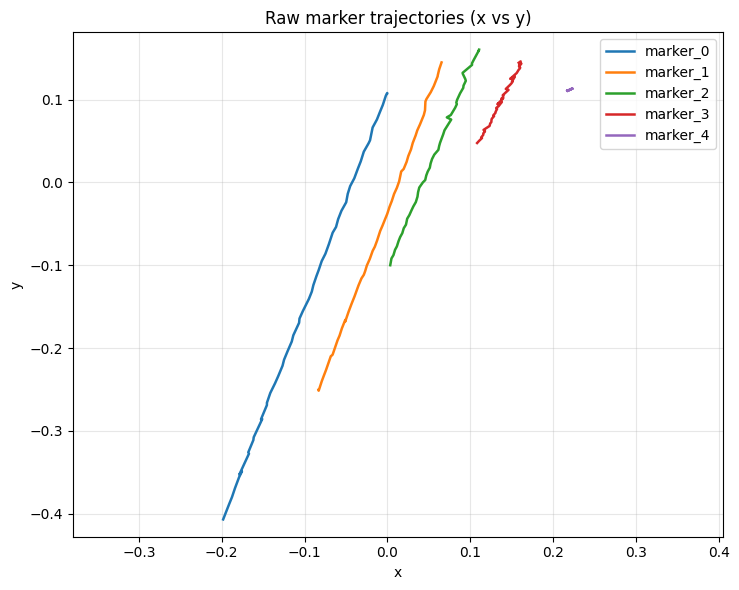

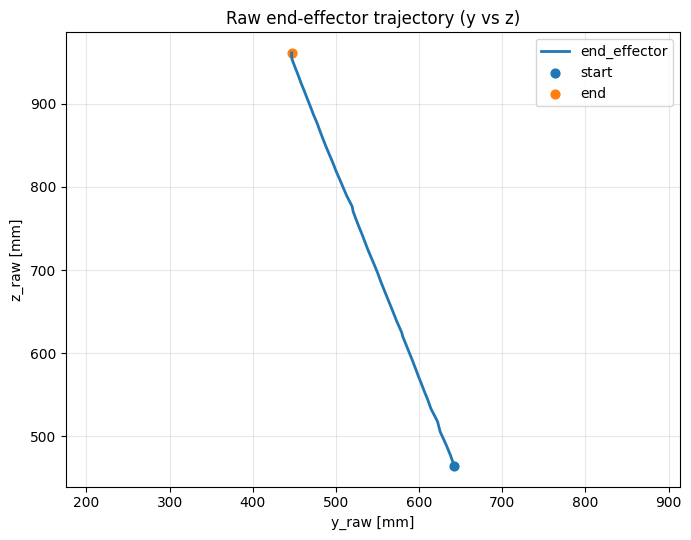

Origin from fixed marker mean:
x0 = 0.21815959529424672
y0 = 0.11105742912687105
z0 = 0.7135054596744795


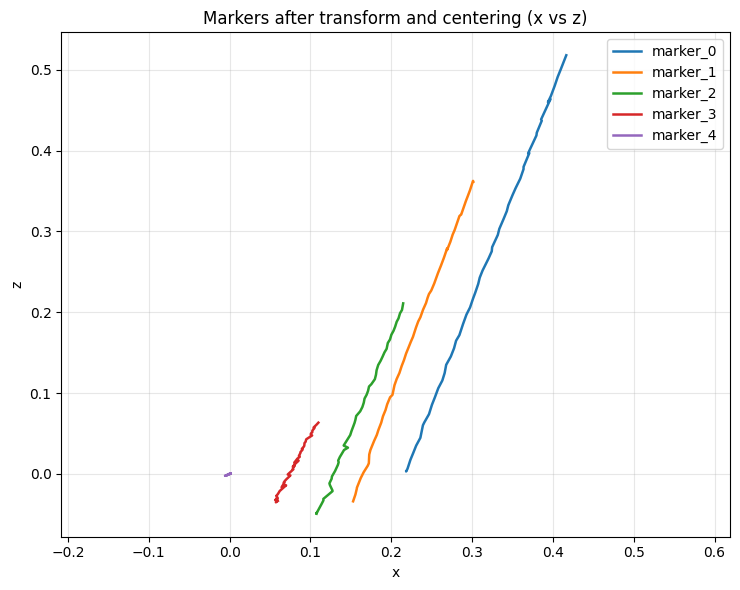

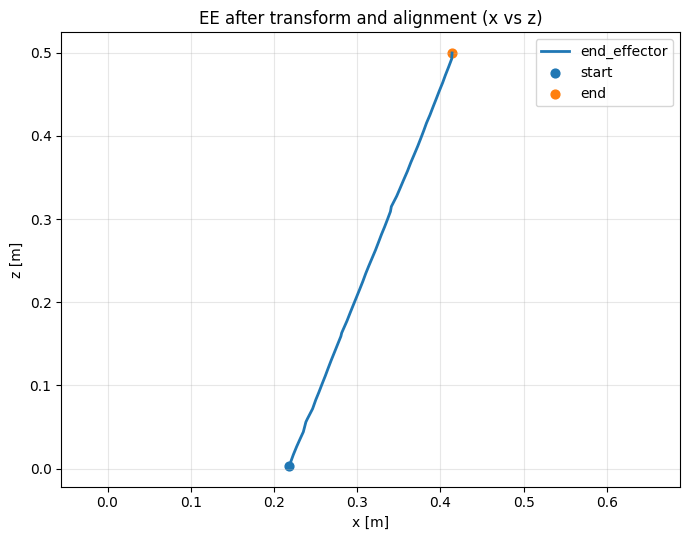

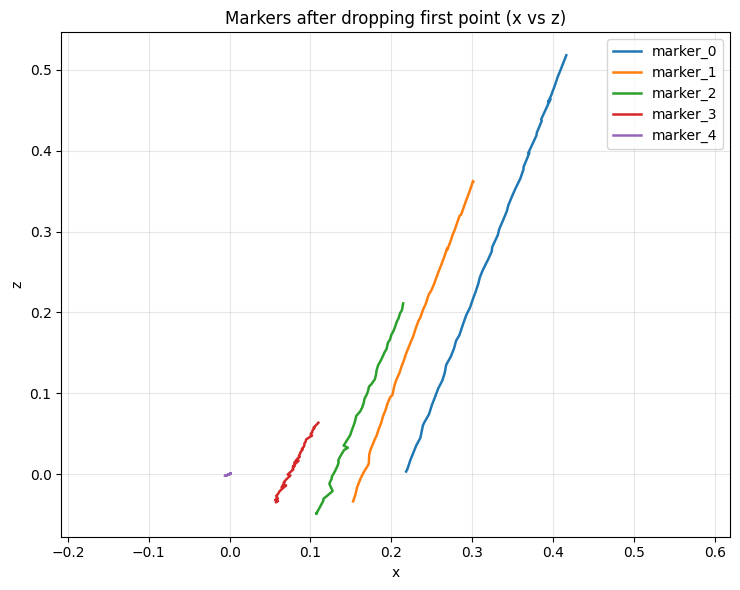

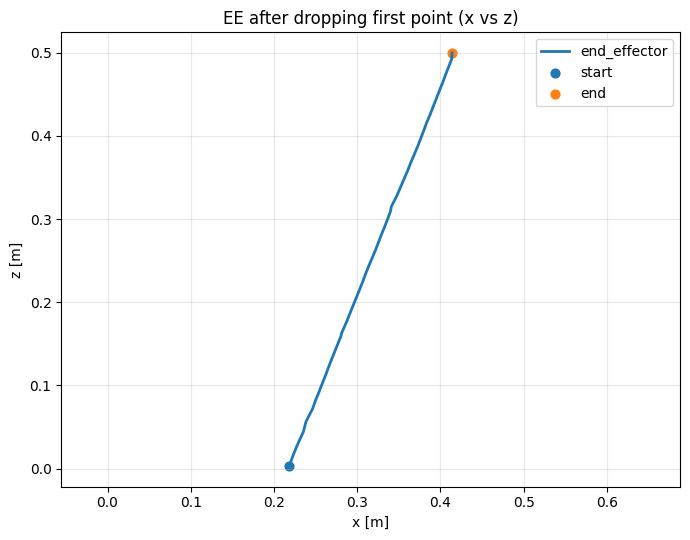

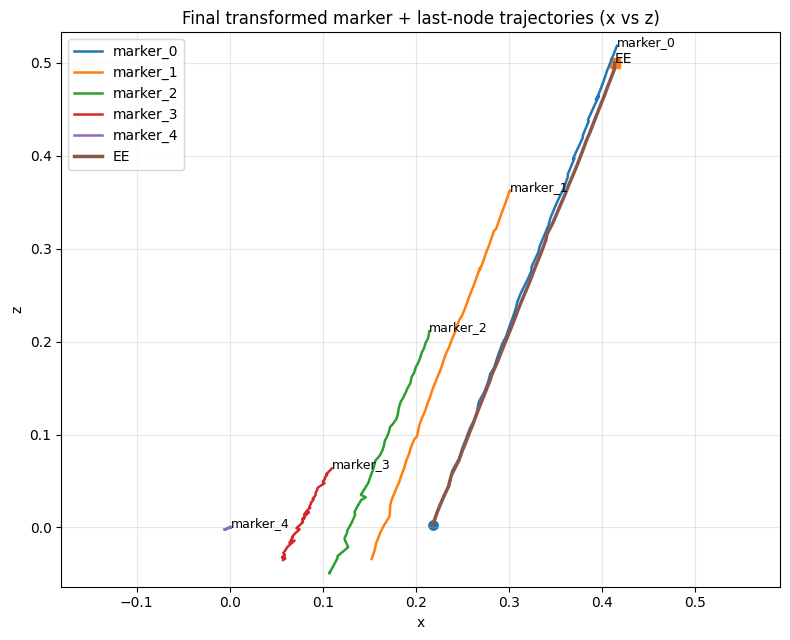

Removing NaNs: kept 53/54 timesteps
Right ghost edge length from frame 0 (marker_0 to marker_1): 0.0752921224453942
target_n_nodes: 7
use_ee_as_last_node: True
prepend_clamped_node_flag: True
append_right_ghost_clamp_flag: True
min_marker_presence_ratio: 0.8
qs shape: (1, 53, 27)
xb shape: (1, 53, 18)
idx_b: [ 0  1  2  3  4  5  6  7 11 15 19 20 21 22 23 24 25 26]
lambdas shape: (1, 53)


In [3]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
if n_nodes == "all" or n_nodes == 5:
    qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=1, n_nodes=n_nodes, \
                                                  prepend_clamped_node_flag=True, append_right_ghost_clamp_flag = True)
elif n_nodes == 3:
    qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_points=1, n_nodes=n_nodes)

In [4]:
print(qs[0,0,:])

[ 0.          0.          0.          0.          0.06830094  0.
  0.          0.          0.12786413  0.         -0.03342521  0.
  0.17572955  0.         -0.04920698  0.          0.22104539  0.
 -0.03387714  0.          0.28664713  0.          0.00309612  0.
  0.36193926  0.          0.00309612]


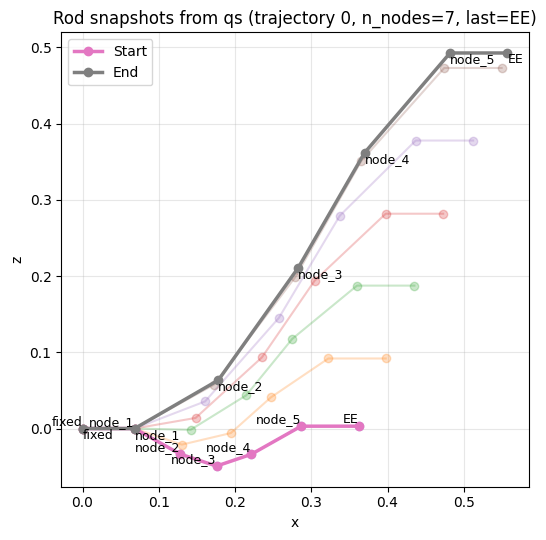

In [5]:
plot_qs_snapshots(qs, every_step=10)

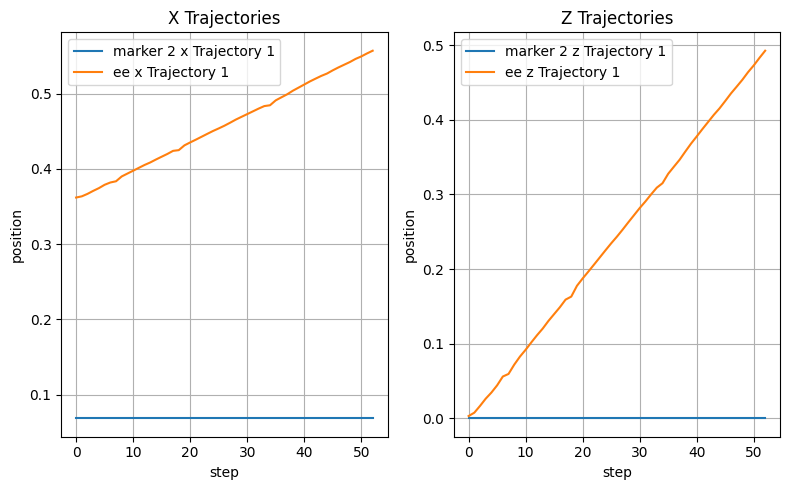

In [6]:
import matplotlib.pyplot as plt
# plot end effector and center marker trajectories for x and z directions

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 4], label=f"marker 2 x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 6], label=f"marker 2 z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()